# RV mocap → ArUco evaluation

Walks through reading the OptiTrack/`mocap4r2` ROS2 bag, visualising the two
rigid bodies, building the ground-truth *marker-in-camera* pose, and comparing
it against an ArUco detector.

See `README.md` for the data description and the two important caveats
(frame conventions + calibration offset).

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
import mocap_rv as mc

BAG = "rv_mocap/rosbag2_2026_06_12-13_53_18"

# Roles inferred from motion. Swap if your setup is the other way round.
CAMERA_BODY, MARKER_BODY = "2", "1" 

## 1. Read the bag and inspect the trajectories

In [2]:
trajs = mc.read_rigid_bodies(BAG)
for name, tr in trajs.items():
    s = mc.summarize(tr)
    print(f"body {name}: n={s['n_samples']}, rate={s['rate_hz']:.1f} Hz, "
          f"path={s['path_length_m']:.2f} m, span(xyz)={np.round(s['pos_span_xyz'],3)}")

body 1: n=1519, rate=79.1 Hz, path=2.53 m, span(xyz)=[1.247 0.271 0.969]
body 2: n=1519, rate=79.1 Hz, path=0.14 m, span(xyz)=[0.002 0.004 0.002]


Body `1` barely moves (the static marker); body `2` sweeps a long path
(the handheld camera).

## 2. World-frame 3D view

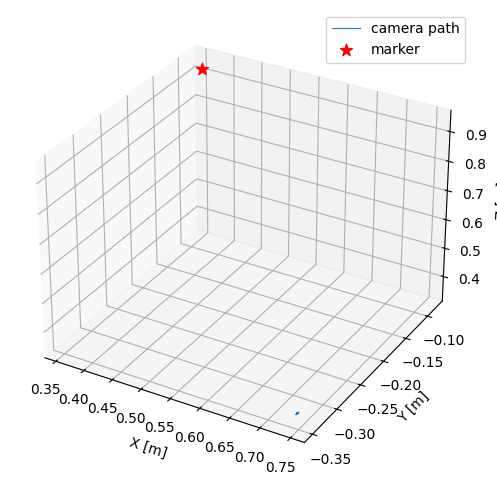

In [3]:
cam, marker = trajs[CAMERA_BODY], trajs[MARKER_BODY]
fig = plt.figure(figsize=(8,6)); ax = fig.add_subplot(111, projection="3d")
ax.plot(*cam.pos.T, lw=0.8, label="camera path")
ax.scatter(*marker.pos.mean(0), color="red", s=80, marker="*", label="marker")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_zlabel("Z [m]")
ax.legend(); plt.show()

## 3. Ground truth: marker pose in the camera frame

marker-camera distance: mean=0.906 m  range=[0.673, 1.152]


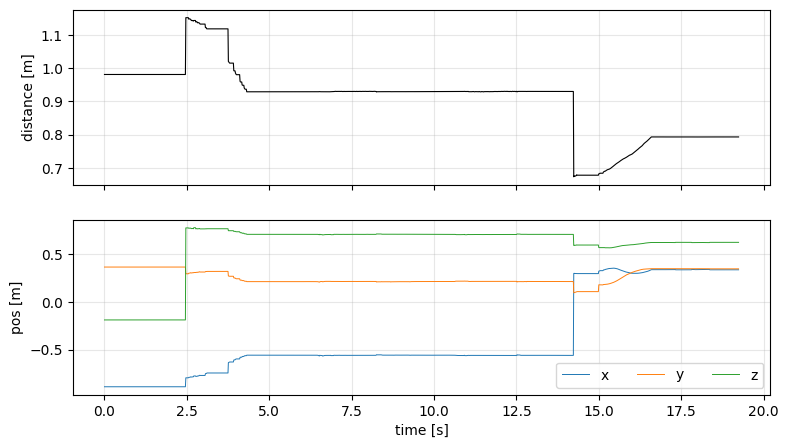

In [4]:
t = cam.t
m_pos, m_quat = mc.resample_to(marker, t)
T_world_cam = cam.matrices()
T_world_marker = np.tile(np.eye(4), (len(t),1,1))
T_world_marker[:, :3, :3] = R.from_quat(m_quat).as_matrix()
T_world_marker[:, :3, 3]  = m_pos

T_cam_marker = mc.relative_pose(T_world_cam, T_world_marker)
rel_pos  = T_cam_marker[:, :3, 3]
rel_quat = R.from_matrix(T_cam_marker[:, :3, :3]).as_quat()
dist = np.linalg.norm(rel_pos, axis=1)
print(f"marker-camera distance: mean={dist.mean():.3f} m  "
      f"range=[{dist.min():.3f}, {dist.max():.3f}]")

fig, axs = plt.subplots(2,1, figsize=(9,5), sharex=True)
axs[0].plot(t, dist, "k", lw=0.8); axs[0].set_ylabel("distance [m]"); axs[0].grid(alpha=.3)
for i,lab in enumerate("xyz"): axs[1].plot(t, rel_pos[:,i], lw=0.7, label=lab)
axs[1].legend(ncol=3); axs[1].set_xlabel("time [s]"); axs[1].set_ylabel("pos [m]")
axs[1].grid(alpha=.3); plt.show()

This `(rel_pos, rel_quat)` is exactly what your ArUco `tvec`/`rvec`
should reproduce (up to the calibration offset described in the README).
It is also saved by `01_parse_and_export.py` to
`output/groundtruth_marker_in_camera.csv`.

## 4. Compare your ArUco estimates

Save your detector output to `output/aruco_estimates.csv` with columns
`t, x, y, z` and either `qx,qy,qz,qw` or `rx,ry,rz`, then run the cell below.
With no file present it falls back to a synthetic noisy example.

In [5]:
import subprocess, sys
print(subprocess.run([sys.executable, "03_compare_aruco.py", "--remove-bias"],
                     capture_output=True, text=True).stdout)

[i] excluding 384 samples in 21 frozen GT windows

=== Error report raw (41 matched samples) ===
  translation: mean=0.6399 m  median=0.6226 m  rmse=0.6417 m  p95=0.7061 m  max=0.7092 m
  rotation   : mean=91.2662 deg  median=95.4901 deg  rmse=91.6123 deg  p95=100.3854 deg  max=101.0100 deg
  wrote output/fig_error_raw.png

=== Error report bias-removed (41 matched samples) ===
  translation: mean=0.0783 m  median=0.0748 m  rmse=0.0857 m  p95=0.1309 m  max=0.1394 m
  rotation   : mean=12.1098 deg  median=13.0816 deg  rmse=13.0042 deg  p95=20.4254 deg  max=21.4035 deg
  wrote output/fig_error_bias-removed.png



The `--remove-bias` pass fits and removes the constant calibration offset;
its residual error is the real measure of detector accuracy.